In [2]:
# 라이브러리
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

In [20]:
# 데이터로 시각화 해보기
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# 데이터 수집
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0])


In [4]:
# 훈련 데이터
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state = 42)

In [5]:
# 데이터 전처리, 모델이 원하는 입력형태로 만들어주기 위해서
train_input = train_input.reshape(-1, 1) # 형태(구조)를 변경해준다. 1차원을 2차원 행렬로.
test_input = test_input.reshape(-1, 1)

In [7]:
# 사이킷런 모델은 X(Feature) 데이터로 2차원 배열을 입력받기 원한다.
model = KNeighborsRegressor()
model.fit(train_input, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# 예측
model.predict([[29]])

array([248.])

In [ ]:
# 평가의 결과는 R**2로 결정계수라고 한다.
model.score(test_input, test_target)

0.992809406101064

In [17]:
from sklearn.metrics import mean_absolute_error

test_prediction = model.predict(test_input) #예측한 결과값
mae = mean_absolute_error(test_target,test_prediction) # MAE 지표를 계산
print(mae) #19.16

19.157142857142862


In [18]:
#k 값의 변화에 따라서, 그래프를 그려보자.
# k 값이 1일 때,5일 때, 10일 때 각각의 차이


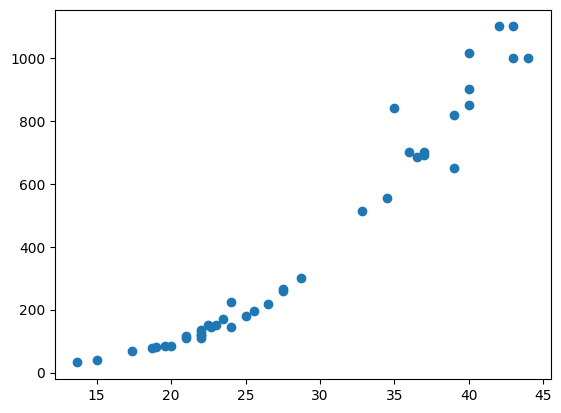

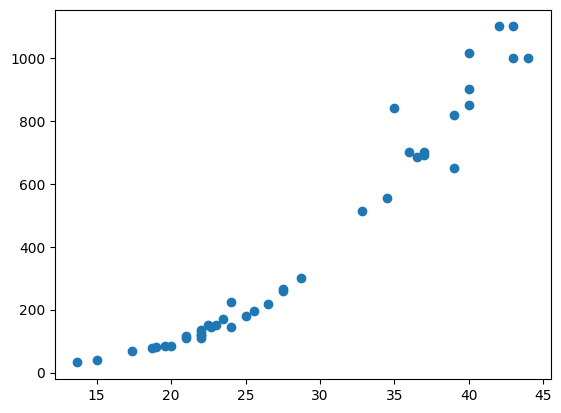

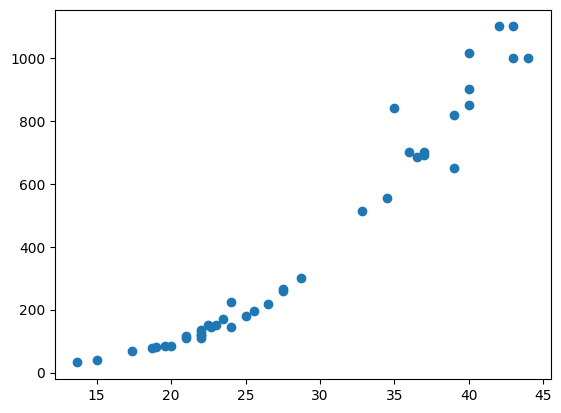

In [22]:
model = KNeighborsRegressor()
x = np.arange(5, 45).reshape(-1, 1)
for n in [1, 5, 10]:
    model.n_neighbors = n
    model.fit(train_input, train_target)
    prediction = model.predict(x)
    plt.scatter(train_input, train_target)
    plt.plot()
    plt.show()

c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning

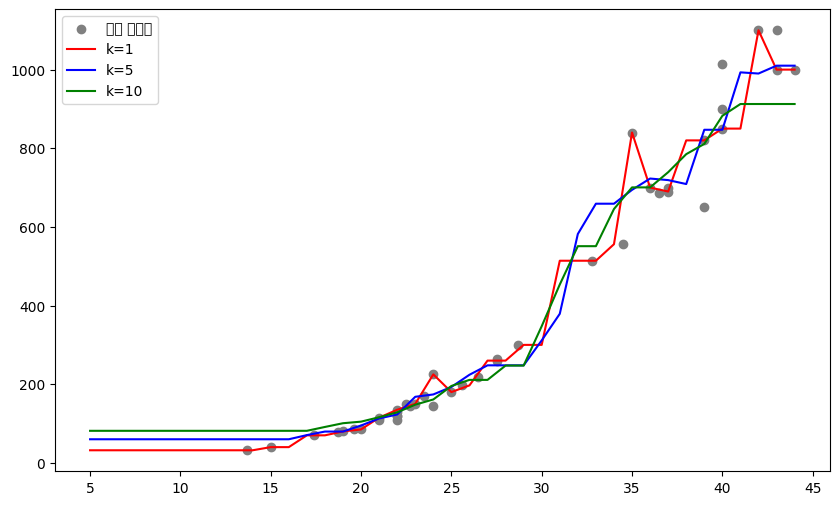

In [23]:
model = KNeighborsRegressor()
x = np.arange(5, 45).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(train_input, train_target, color='grey', label='실제 데이터')

for n, color in zip([1, 5, 10], ['red', 'blue', 'green']):
    model.n_neighbors = n
    model.fit(train_input, train_target)
    prediction = model.predict(x)
    plt.plot(x, prediction, color=color, label=f'k={n}')  # ← x, prediction 추가

plt.legend()
plt.show() 

In [25]:
# 선형 회귀
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(train_input, train_target)

# 예측
model.predict([[50]])
model.score(test_input, test_target) #결정계수

0.824750312331356

In [ ]:
# w
print("w:", model.coef_)
# b
print("b", model.intercept_)

w: [39.01714496]
b -709.0186449535474


c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45453 (\N{HANGUL SYLLABLE NONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarni

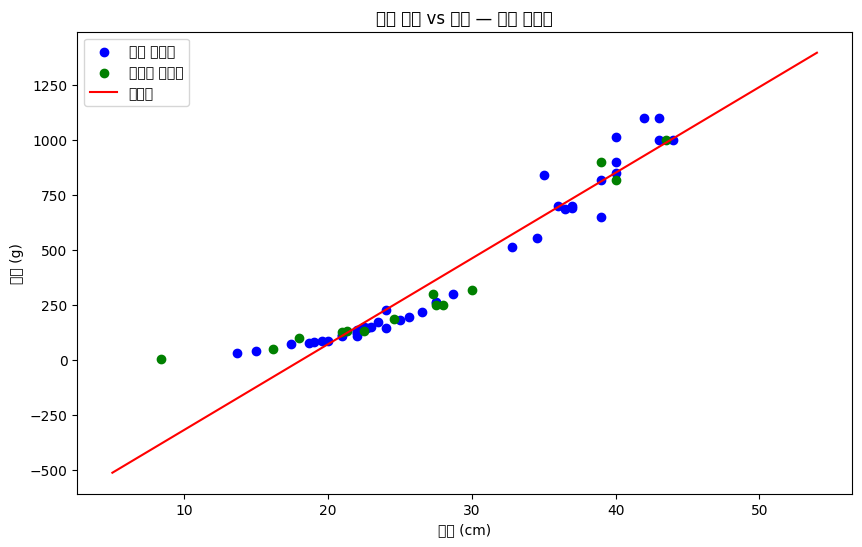

기울기(w): 39.02
절편(b): -709.02
R²: 0.8248


In [27]:
# 회귀선이 담긴 그래프
x = np.arange(5, 55).reshape(-1, 1)   # x축 범위 (5~54cm)
prediction = model.predict(x)          # 각 x에 대한 예측 무게

plt.figure(figsize=(10, 6))
plt.scatter(train_input, train_target, color='blue', label='훈련 데이터')   # 실제 점
plt.scatter(test_input, test_target, color='green', label='테스트 데이터')  # 실제 점
plt.plot(x, prediction, color='red', label='회귀선')                        # 직선

plt.xlabel('길이 (cm)')
plt.ylabel('무게 (g)')
plt.title('농어 길이 vs 무게 — 선형 회귀선')
plt.legend()
plt.show()

print(f"기울기(w): {model.coef_[0]:.2f}")      # 길이 1cm 늘수록 무게 몇g 증가
print(f"절편(b): {model.intercept_:.2f}")       # 길이가 0일 때 무게 (이론값)
print(f"R²: {model.score(test_input, test_target):.4f}")

In [28]:
print(model.score(train_input, train_target))
print(model.score(test_input, test_target)) #결정계수

0.9398463339976041
0.824750312331356


In [ ]:
from sklearn.metrics import mean_squared_error
mean_squared_error(test_target, test_prediction)

# 손실함수를 최소화시키는것이 선형회귀의 학습이다.

721.7385714285714

다항회귀

In [32]:
# 방법 1: 수동 (Ch03-2)
train_poly = np.column_stack((train_input**2, train_input))
print(train_poly[:2])


# 방법 2: PolynomialFeatures (Ch03-3, 오늘 오후)
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)                          
train_poly = poly.transform(train_input)
test_poly  = poly.transform(test_input)
print(train_poly[:2])        

# train에만 fit
# transform만

[[384.16  19.6 ]
 [484.    22.  ]]
[[ 19.6  384.16]
 [ 22.   484.  ]]


In [42]:
model = LinearRegression()
model.fit(train_poly, train_target) #학습
model.predict([[50, 50**2]])
 # 예측 50cm 농어의 예측된 무게는?

array([1573.98423528])

In [34]:
# parameter 구하기 
print(model.coef_)  # w 가중치 [ x**2, x] 계수
print(model.intercept_) # b: y절편

[-21.55792498   1.01433211]
116.05021078278372


In [38]:
#2차 방정식
1x**2 - 21x + 116

SyntaxError: invalid decimal literal (2067737734.py, line 2)

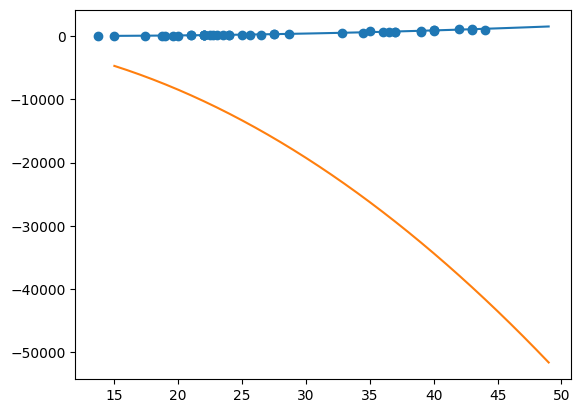

In [40]:
# 시각화
point = np.arange(15, 50) # 점의 범위 정의
plt.scatter(train_input, train_target)
plt.plot(point, 1.01*point**2-21*point+116)
plt.plot(point, model.coef_[0]*point**2 +model.coef_[1]*point+model.intercept_)
plt.show()

In [ ]:
test_poly = np.column_stack(((test_input**2, test_input)))
print(model.score(test_poly,test_target))

ValueError: Expected 2D array, got 1D array instead:
array=[   5.9  100.   250.   130.   130.   820.   320.   188.   900.   125.
 1000.    51.5  250.   300. ].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [45]:
print(test_poly[:3])

[[ 70.56   8.4 ]
 [324.    18.  ]
 [756.25  27.5 ]]


In [46]:
print(train_input.shape)
print(test_input.shape)

(42, 1)
(14, 1)


In [47]:
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly  = poly.transform(test_input)

In [48]:
print("\n=== 다항 회귀 ===")
print("train_poly 형태:", train_poly.shape)
print("train_poly 앞 2개:", train_poly[:2])


=== 다항 회귀 ===
train_poly 형태: (42, 2)
train_poly 앞 2개: [[ 19.6  384.16]
 [ 22.   484.  ]]


In [49]:
poly_model = LinearRegression()
poly_model.fit(train_poly, train_target)

print("w:", poly_model.coef_)
print("b:", poly_model.intercept_)
print("train R²:", poly_model.score(train_poly, train_target))
print("test R²:", poly_model.score(test_poly, test_target))
print("50cm 예측:", poly_model.predict([train_poly[0]]))  


w: [-21.55792498   1.01433211]
b: 116.05021078278372
train R²: 0.9706807451768623
test R²: 0.9775935108325123
50cm 예측: [83.18070434]


c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54637 (\N{HANGUL SYLLABLE HANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarni

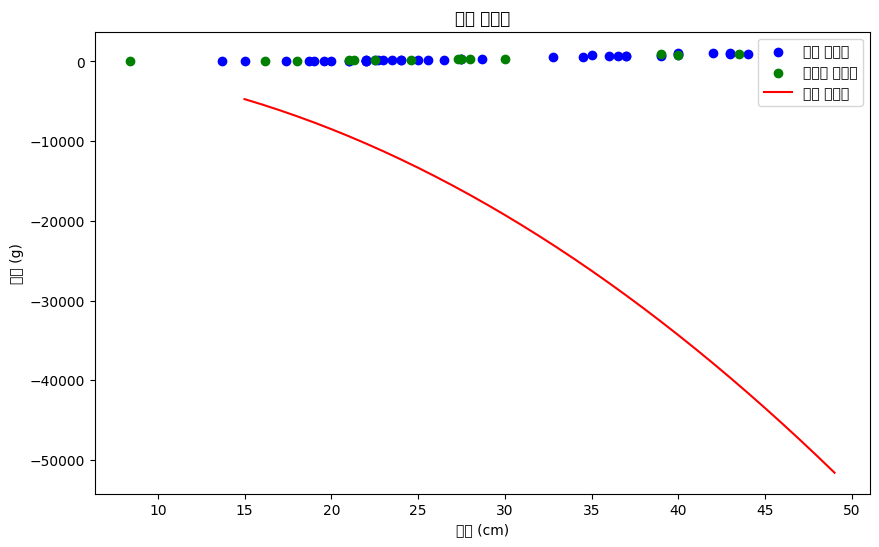

In [50]:
# 다항 회귀 그래프
point = np.arange(15, 50)
plt.figure(figsize=(10, 6))
plt.scatter(train_input, train_target, color='blue', label='훈련 데이터')
plt.scatter(test_input, test_target, color='green', label='테스트 데이터')
plt.plot(point,
         poly_model.coef_[0]*point**2 + poly_model.coef_[1]*point + poly_model.intercept_,
         color='red', label='다항 회귀선')
plt.xlabel('길이 (cm)')
plt.ylabel('무게 (g)')
plt.title('다항 회귀선')
plt.legend()
plt.show()